# Assignment

Use the "from the expert" (FTE) jupyter notebook as a starter for this assignment, and ask your instructor questions if you need help.

Welcome to your first assignment in the Introduction to Data Science course. This assignment will help you apply fundamental data science concepts, such as exploratory data analysis (EDA), and basic data visualization. You will work with the churn dataset and use Python to perform various tasks. This assignment will test your ability to manipulate data, generate insights, and effectively communicate your findings. Remember, your instructor is here to support you if you encounter any issues. Make sure to approach each task methodically. Good luck!

Dataset Information:
For this assignment, you will be using the churn dataset provided as a CSV file. The dataset includes various columns representing different characterics of customers. Your task is to clean the dataset, explore it, and extract insights through visualization and fundamental statistical analysis.
Instructions


Task 1: Exploratory Data Analysis (EDA)
1.	Provide a summary of the dataset, including the numerical columns' mean, median, and standard deviation.
2.	Explore the relationships between variables through visualizations such as histograms, scatter plots, and box plots.
3.	Identify any patterns or trends in the data, such as correlations between variables, outliers, or significant groupings.
4.	Provide a narrative of your findings based on your analysis.

Task 3: Data Visualization
1.	Create at least three visualizations that effectively communicate insights from the data.
2.	Use Matplotlib, Seaborn, or Plotly to create visualizations.
3.	Ensure that your visualizations are well-labeled and easy to interpret.
4.	Accompany each visualization, briefly explaining what it shows and why it is relevant.

Submission Guidelines:
1.	Submit your Python code in a Jupyter Notebook format (.ipynb).
2.	Ensure your notebook is well-organized, with explicit comments explaining each process step.
3.	**Include a BRIEF! narrative of your findings in markdown format at the end of your notebook.**
4.	Name your files using the following format: LastName_FirstName_Assignment1.
5.	Upload your submission through the course portal before the deadline.


## Data science process steps this week
We will carry out the first two parts of the CRISP-DM data science process this week:

1. Business understanding

This is customer churn data for a telecommunications company. Customers can have phone as well as other services. The company is looking to reduce customer churn, where customers stop using the company's services and cancel their account. The 'Churn' column has a binary target, yes or no, that denotes if a customer churned. We want to create a machine learning model to predict the Churn target using the other available data in the dataset. Ideally, we will deploy this model to integrate with the company's database, so that a churn risk column is created for each customer. This will enable customer service reps and others to devise and use strategies to reduce churn.


2. Data understanding

Follow the instructions in Tasks 1 and 2 above.

In [1]:
import pandas as pd

'''
Importing our data set
'''
df_churn = pd.read_csv('./churn_data/churn_data.csv')
df_churn

,customerID,tenure,PhoneService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Yes,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,Month-to-month,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...
7038,6840-RESVB,24,Yes,One year,Mailed check,84.80,1990.50,No
7039,2234-XADUH,72,Yes,One year,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,11,No,Month-to-month,Electronic check,29.60,346.45,No
7041,8361-LTMKD,4,Yes,Month-to-month,Mailed check,74.40,306.60,Yes


In [2]:
df_churn.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [3]:
'''
Getting our mean, standard deviation, and median values for the numerical columns
This includes only tenure, monthly charges, and total charges
'''
tenure = df_churn['tenure']
monthly_charges = df_churn['MonthlyCharges']
total_charges = df_churn['TotalCharges']

print('Mean Values:')
print('Tenure = ', round(tenure.mean(),2))
print('Monthly Charges = ', round(monthly_charges.mean(),2))
print('Total Charges = ', round(total_charges.mean(),2))
print('\nStandard Deviation Values:')
print('Tenure = ', round(tenure.std(),2))
print('Monthly Charges = ', round(monthly_charges.std(),2))
print('Total Charges = ', round(total_charges.std(),2))
print('\nMedian Values:')
print('Tenure = ', round(tenure.median(),2))
print('Monthly Charges = ', round(monthly_charges.median(),2))
print('Total Charges = ', round(total_charges.median(),2))


Mean Values:
Tenure =  32.37
Monthly Charges =  64.76
Total Charges =  2283.3

Standard Deviation Values:
Tenure =  24.56
Monthly Charges =  30.09
Total Charges =  2266.77

Median Values:
Tenure =  29.0
Monthly Charges =  70.35
Total Charges =  1397.47


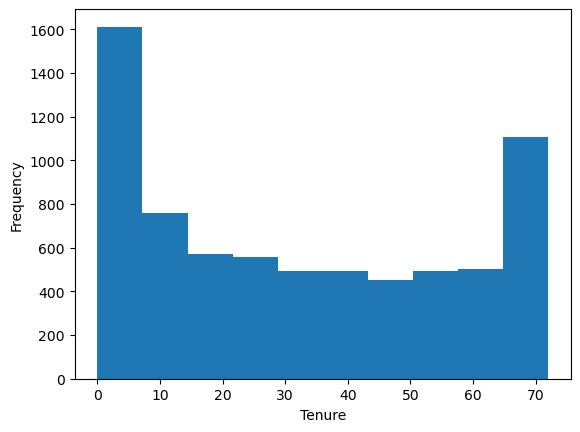

In [4]:
import matplotlib.pyplot as plt

tenure.plot.hist()
_ = plt.xlabel('Tenure')

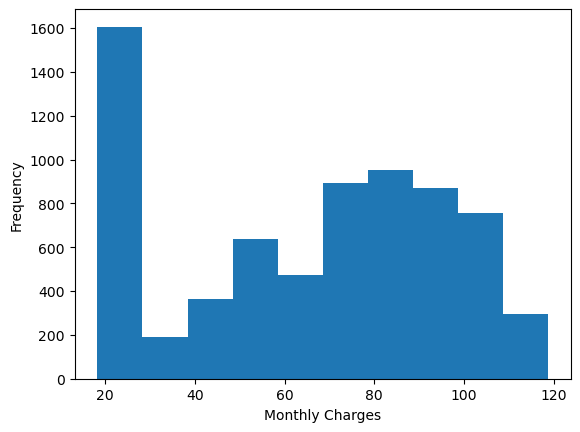

In [5]:
monthly_charges.plot.hist()
_ = plt.xlabel('Monthly Charges')

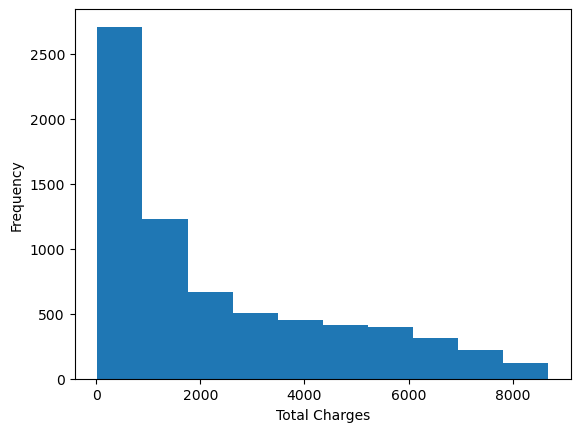

In [6]:
total_charges.plot.hist()
_ = plt.xlabel('Total Charges')

Average monthly charge of people who left phone company: $ 74.44
Average monthly charge of people who did not leave the phone company: $ 61.27


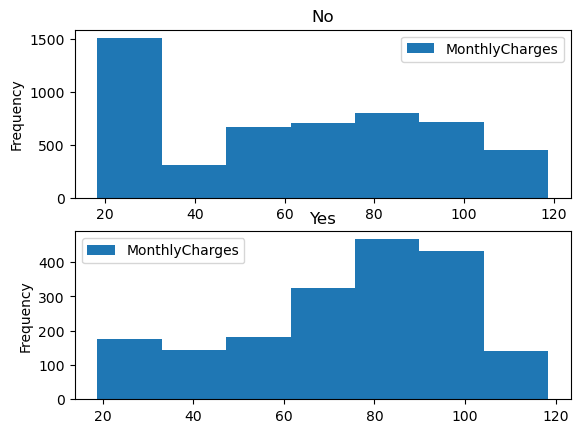

In [12]:
'''
Creating two histograms for monthly charges grouped by churn
Seems that people who did leave had higher monthly charges on average
'''
_ = df_churn.plot.hist(column='MonthlyCharges', by='Churn', bins=7)

'''
Calculating the mean monthly charges for people who left vs people who stayed.
'''
df_churn_yes = df_churn[df_churn['Churn'] == 'Yes']
df_churn_no = df_churn[df_churn['Churn'] == 'No']
print('Average monthly charge of people who left phone company: $', round(df_churn_yes['MonthlyCharges'].mean(), 2))
print('Average monthly charge of people who did not leave the phone company: $', round(df_churn_no['MonthlyCharges'].mean(), 2))

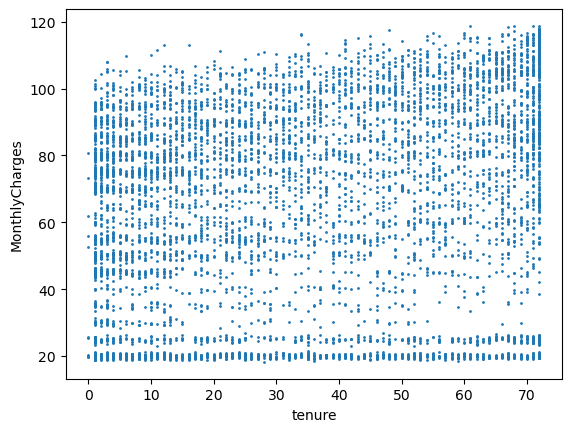

In [13]:
'''
Being with the company for a long time does not seem to impact your monthly charges.
'''
_ = df_churn.plot.scatter(x='tenure', y='MonthlyCharges', s=1)

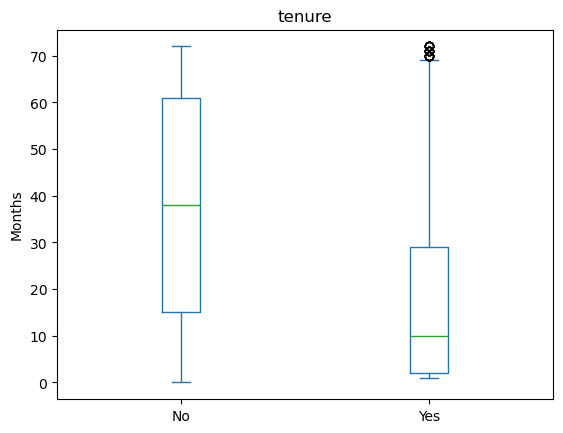

In [14]:
'''
It seems that people who churn are generally newer customers
'''
df_churn.plot.box(column='tenure', by='Churn')
_ = plt.ylabel('Months')

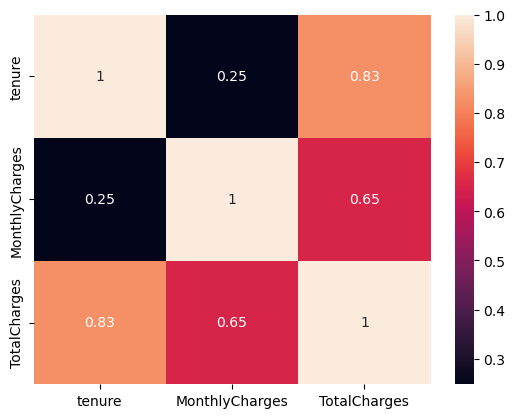

In [15]:
'''
Finding the correlation coefficient for the numeric variables
'''

import seaborn as sns
import numpy as np
import phik

df_churn_numeric = df_churn.select_dtypes(include=[np.number])
_ = sns.heatmap(df_churn_numeric.corr(), annot=True)

interval columns not set, guessing: ['tenure', 'MonthlyCharges', 'TotalCharges']


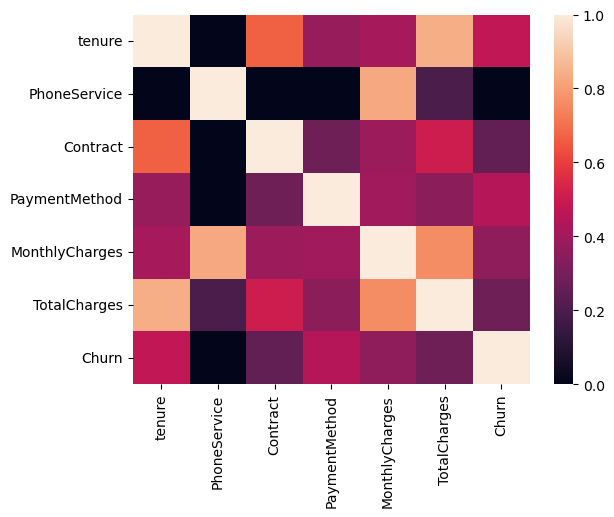

In [18]:
'''
Finding the correlation coefficient for all variables
'''

df_churn_no_customer_ID = df_churn.drop('customerID', axis=1)
_ = sns.heatmap(df_churn_no_customer_ID.phik_matrix())

Based on our analysis, it seems that whether or not someone stays with the phone company or decides to churn is heavily based off of how long they have been with the phone company and how much they are being charged on a monthly basis.  People who have been with the company for a long time are less likely to leave.  People with high monthly bills are more likely to leave.  There is also some outliers of people who have been with the company for a long time and still churn.

In addition, the categorical phik heat map shows that there is a correlation between churn and payment method.  This may be due to an underlining relationship between age and churn.  For example, people who mail checks are generally older people and people who use a credit card or electronic check are generally younger.  Older people are more financially stable and because of this, they may be less likely to leave the phone service.